In [ ]:
!pip install opendatasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od
import matplotlib.ticker as mtick

In [ ]:
#Token = KGAT_15adf665fa30f189decf7208aa1972a1

In [ ]:
dataset_url = "https://www.kaggle.com/datasets/hendratno/cause-of-death-in-indonesia"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: akialgrowto
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/hendratno/cause-of-death-in-indonesia


100%|██████████| 21.6k/21.6k [00:00<00:00, 12.2MB/s]

In [ ]:
df = pd.read_csv('/content/cause-of-death-in-indonesia/Penyebab Kematian di Indonesia yang Dilaporkan - Clean (2).csv')

#5 data teratas
df.head()

,Cause,Type,Year,Data Redundancy,Total Deaths,Source,Page at Source,Source URL
0,Abrasi Air Laut,Bencana Alam,2012,1,0,Profil Kesehatan Indonesia Tahun 2012,Lampiran 3.38,https://pusdatin.kemkes.go.id/download.php?fil...
1,AIDS,Bencana Non Alam dan Penyakit,2000,1,47,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
2,AIDS,Bencana Non Alam dan Penyakit,2001,1,99,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
3,AIDS,Bencana Non Alam dan Penyakit,2002,1,100,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
4,AIDS,Bencana Non Alam dan Penyakit,2003,1,261,Profil Kesehatan Indonesia Tahun 2010,115,https://pusdatin.kemkes.go.id/download.php?fil...


In [ ]:
df.tail()

,Cause,Type,Year,Data Redundancy,Total Deaths,Source,Page at Source,Source URL
675,Wabah Penyakit (Epidemi),Bencana Non Alam dan Penyakit,2016,1,0,Profil Kesehatan Indonesia Tahun 2016,Lampiran 6.37,https://pusdatin.kemkes.go.id/download.php?fil...
676,Wabah Penyakit (Epidemi),Bencana Non Alam dan Penyakit,2017,1,0,Profil Kesehatan Indonesia Tahun 2017,Lampiran 6.43,https://pusdatin.kemkes.go.id/download.php?fil...
677,Wabah Penyakit (Epidemi),Bencana Non Alam dan Penyakit,2019,1,0,Profil Kesehatan Indonesia Tahun 2019,Lampiran 63.c,https://pusdatin.kemkes.go.id/download.php?fil...
678,Wabah Penyakit (Epidemi),Bencana Non Alam dan Penyakit,2020,1,0,Profil Kesehatan Indonesia Tahun 2020,191,https://pusdatin.kemkes.go.id/download.php?fil...
679,Wabah Penyakit (Epidemi),Bencana Non Alam dan Penyakit,2021,1,0,Profil Kesehatan Indonesia Tahun 2021,253,https://www.kemkes.go.id/downloads/resources/d...


In [ ]:
df.columns

Index(['Cause', 'Type', 'Year', 'Data Redundancy', 'Total Deaths', 'Source',
       'Page at Source', 'Source URL'],
      dtype='object')

In [ ]:
print('Number of Rows: {}'.format(df.shape[0]))
print('Number of Cols: {}'.format(df.shape[1]))

Number of Rows: 680
Number of Cols: 8


# Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Cause            680 non-null    object
 1   Type             680 non-null    object
 2   Year             680 non-null    int64 
 3   Data Redundancy  680 non-null    int64 
 4   Total Deaths     680 non-null    int64 
 5   Source           680 non-null    object
 6   Page at Source   678 non-null    object
 7   Source URL       677 non-null    object
dtypes: int64(3), object(5)
memory usage: 42.6+ KB


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
675,False
676,False
677,False
678,False


In [ ]:
df.isnull().sum()

,0
Cause,0
Type,0
Year,0
Data Redundancy,0
Total Deaths,0
Source,0
Page at Source,2
Source URL,3


In [ ]:
df1 = df.dropna()

In [ ]:
df1.isnull().sum()

,0
Cause,0
Type,0
Year,0
Data Redundancy,0
Total Deaths,0
Source,0
Page at Source,0
Source URL,0


In [ ]:
duplikat = df1.astype(str).duplicated().sum()
print(f"Jumlah data duplikat: {duplikat}")

Jumlah data duplikat: 0


In [ ]:
df1.columns

Index(['Cause', 'Type', 'Year', 'Data Redundancy', 'Total Deaths', 'Source',
       'Page at Source', 'Source URL'],
      dtype='object')

In [ ]:
df1.head()

,Cause,Type,Year,Data Redundancy,Total Deaths,Source,Page at Source,Source URL
0,Abrasi Air Laut,Bencana Alam,2012,1,0,Profil Kesehatan Indonesia Tahun 2012,Lampiran 3.38,https://pusdatin.kemkes.go.id/download.php?fil...
1,AIDS,Bencana Non Alam dan Penyakit,2000,1,47,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
2,AIDS,Bencana Non Alam dan Penyakit,2001,1,99,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
3,AIDS,Bencana Non Alam dan Penyakit,2002,1,100,Profil Kesehatan Indonesia Tahun 2004,78,https://pusdatin.kemkes.go.id/download.php?fil...
4,AIDS,Bencana Non Alam dan Penyakit,2003,1,261,Profil Kesehatan Indonesia Tahun 2010,115,https://pusdatin.kemkes.go.id/download.php?fil...


# EDA

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 677 entries, 0 to 679
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Cause            677 non-null    object
 1   Type             677 non-null    object
 2   Year             677 non-null    int64 
 3   Data Redundancy  677 non-null    int64 
 4   Total Deaths     677 non-null    int64 
 5   Source           677 non-null    object
 6   Page at Source   677 non-null    object
 7   Source URL       677 non-null    object
dtypes: int64(3), object(5)
memory usage: 47.6+ KB


In [ ]:
df1.describe()

,Year,Data Redundancy,Total Deaths
count,677.000000,677.0,677.000000
mean,2010.514032,1.0,1222.680945
std,5.744706,0.0,5931.534262
min,2000.000000,1.0,0.000000
25%,2005.000000,1.0,4.000000
50%,2009.000000,1.0,35.000000
75%,2016.000000,1.0,291.000000
max,2021.000000,1.0,129171.000000


In [ ]:
hasil = df.groupby('Year')['Total Deaths'].sum()

# Output langsung berupa teks
print("Hasil Jumlah Kematian:")
for tahun, jumlah in hasil.items():
    print(f"Tahun {tahun}: {jumlah}")

Hasil Jumlah Kematian:
Tahun 2000: 339
Tahun 2001: 324
Tahun 2002: 435
Tahun 2003: 633
Tahun 2004: 220744
Tahun 2005: 123036
Tahun 2006: 127065
Tahun 2007: 89275
Tahun 2008: 106298
Tahun 2009: 33124
Tahun 2010: 39261
Tahun 2011: 2173
Tahun 2012: 1834
Tahun 2013: 1145
Tahun 2014: 1199
Tahun 2015: 2356
Tahun 2016: 2624
Tahun 2017: 1044
Tahun 2018: 4976
Tahun 2019: 14697
Tahun 2020: 38063
Tahun 2021: 139106
Tahun 2022: 12876


In [ ]:
print("Penyebab Kematian  :", df1["Type"].nunique(), "kategori")
# Cek nilai unik di kolom target
df1["Cause"].unique()
df1["Type"].unique()

Penyebab Kematian  : 3 kategori


array(['Bencana Alam', 'Bencana Non Alam dan Penyakit', 'Bencana Sosial'],
      dtype=object)

In [ ]:
df1["Type"].value_counts(normalize=True)

,proportion
Type,
Bencana Non Alam dan Penyakit,0.751846
Bencana Alam,0.218612
Bencana Sosial,0.029542


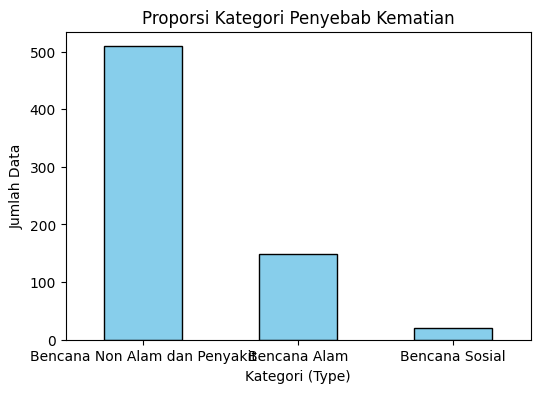

In [ ]:
# Visualisasi distribusi Type
plt.figure(figsize=(6,4))
df1["Type"].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Proporsi Kategori Penyebab Kematian")
plt.xlabel("Kategori (Type)")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()


=== JUMLAH DATA PER KATEGORI ===
Type
Bencana Non Alam dan Penyakit    509
Bencana Alam                     148
Bencana Sosial                    20
Name: count, dtype: int64

=== PROPORSI (%) PER KATEGORI ===
Type
Bencana Non Alam dan Penyakit    75.18
Bencana Alam                     21.86
Bencana Sosial                    2.95
Name: proportion, dtype: float64

=== TABEL PROPORSI DATA ===
                               Jumlah Data  Proporsi (%)
Type                                                    
Bencana Non Alam dan Penyakit          509         75.18
Bencana Alam                           148         21.86
Bencana Sosial                          20          2.95


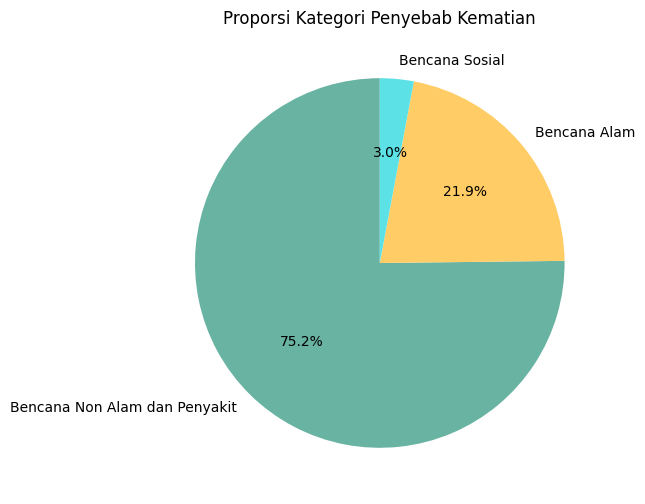

In [ ]:
# --- 1. Hitung jumlah data per kategori ---
type_count = df1['Type'].value_counts()
print("=== JUMLAH DATA PER KATEGORI ===")
print(type_count)

# --- 2. Hitung proporsi (persentase) ---
type_proporsi = df1['Type'].value_counts(normalize=True) * 100
print("\n=== PROPORSI (%) PER KATEGORI ===")
print(type_proporsi.round(2))

# --- 3. Gabungkan dalam satu DataFrame agar rapi ---
proporsi_df = pd.DataFrame({
    'Jumlah Data': type_count,
    'Proporsi (%)': type_proporsi.round(2)
})
print("\n=== TABEL PROPORSI DATA ===")
print(proporsi_df)

# --- 4. Visualisasi Pie Chart ---
plt.figure(figsize=(6,6))
plt.pie(
    type_proporsi,
    labels=type_proporsi.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#69b3a2', '#ffcc66', '#5ce1e6']
)
plt.title("Proporsi Kategori Penyebab Kematian")
plt.show()

Data Distribusi

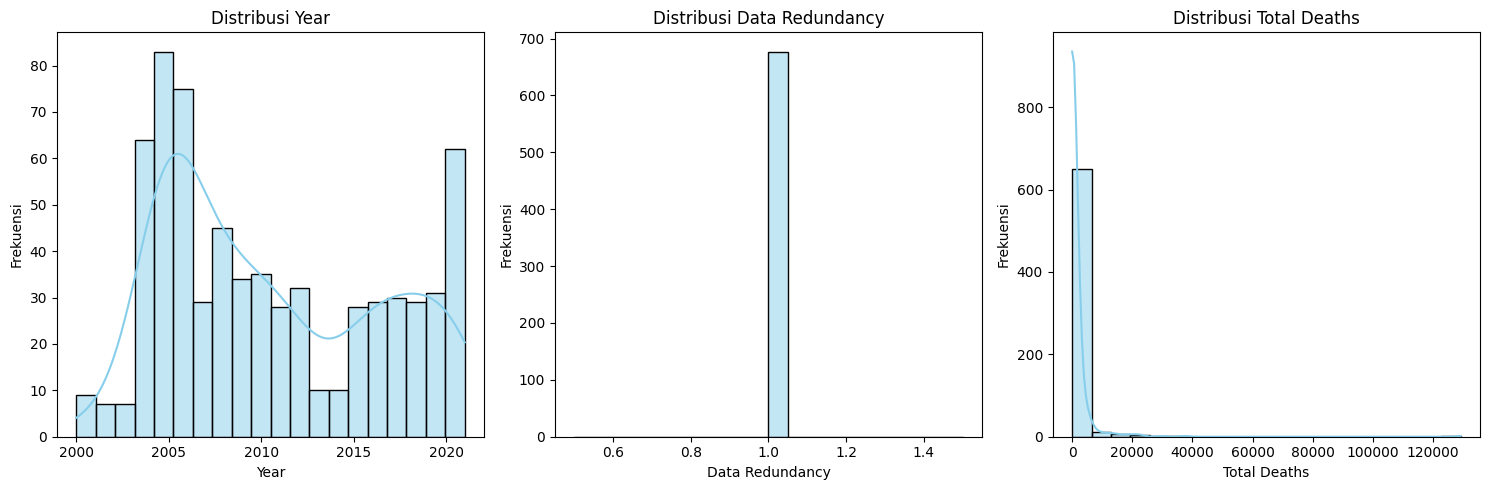

In [ ]:
num_cols = ['Year', 'Data Redundancy', 'Total Deaths']

plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df1[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribusi {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()